# FJC Integrated Database — Securities Cases EDA

**Source:** Federal Judicial Center (FJC) Integrated Database via WRDS  
**Schema:** `fjc.civil`  
**Filter:** `nos = 850` (Securities / Commodities / Exchange)  
**Coverage:** 1980–2025 (2025 partial — court reporting lag; most recent year undercounts)  

**Reference:** `~/projects/workflows/skills/wrds/references/fjc.md`  
**Obsidian:** `Resources/Data/FJC Integrated Database.md`

### Key limitations
- `section` field identifies statute (§78 = Exchange Act, §77 = Securities Act) but is NULL/uncoded for ~42% of NOS=850 cases
- `subsect` field (sub-provision: §10(b), §11, §12) is sparsely coded — cannot reliably distinguish Rule 10b-5 vs §11 vs §12
- `class_action` flag is NULL for ~71% of cases (coded primarily post-1990)
- Placeholder dates: filter `filedate >= '1970-01-01'`
- No dedup needed: each row is a unique case (docket + district + office)
- Recent years (2025+) have fewer cases due to court reporting lag — treat as incomplete


In [1]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'figure.dpi': 300,
})

## 1. Connect & Pull Data

In [2]:
# Credentials from ~/.pgpass — no password in code
conn = psycopg2.connect(
    host='wrds-pgdata.wharton.upenn.edu',
    port=9737,
    database='wrds',
    user='eddyhu',
    sslmode='require'
)

# NOS=850: Securities / Commodities / Exchange
# No additional filters needed (unlike Compustat which requires indfmt/datafmt/popsrc/consol)
query = """
SELECT
    filedate,
    EXTRACT(YEAR FROM filedate)::int AS fileyear,
    COALESCE(section, '')            AS section,
    COALESCE(subsect, '')            AS subsect,
    class_action,
    disp,
    judgment,
    amtrec,
    demanded,
    circuit::int                     AS circuit,
    district,
    jury
FROM fjc.civil
WHERE nos = 850
  AND filedate >= '1980-01-01'
"""

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    df = pd.read_sql(query, conn, parse_dates=['filedate'])
conn.close()

print(f'Rows: {len(df):,}')
print(f'Date range: {df.filedate.min().date()} — {df.filedate.max().date()}')
df.head(3)

Rows: 90,882
Date range: 1980-01-01 — 2025-12-16


,filedate,fileyear,section,subsect,class_action,disp,judgment,amtrec,demanded,circuit,district,jury
0,1983-05-31,1983,,,0.0,5.0,4.0,0.0,0.0,0,90,None
1,1980-07-30,1980,,,0.0,6.0,4.0,0.0,0.0,0,90,None
2,1981-01-22,1981,,,0.0,3.0,4.0,0.0,0.0,0,90,None


## 2. Dedup Check

Each row should be a unique case. Verify there are no duplicates on the natural key.

In [3]:
# Natural key: filedate + district + circuit (docket not in our pull but unique within district)
# Check for exact row duplicates
n_dupes = df.duplicated().sum()
print(f'Exact duplicate rows: {n_dupes}')

# Verify: pull with docket to check uniqueness
conn2 = psycopg2.connect(
    host='wrds-pgdata.wharton.upenn.edu', port=9737,
    database='wrds', user='eddyhu', sslmode='require'
)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    df_key = pd.read_sql("""
        SELECT filedate, docket, circuit::int, district, office, COUNT(*) as n
        FROM fjc.civil
        WHERE nos = 850
          AND filedate >= '1980-01-01'
        GROUP BY filedate, docket, circuit, district, office
        HAVING COUNT(*) > 1
        LIMIT 20
    """, conn2)
conn2.close()

print(f'Rows with duplicate (filedate, docket, circuit, district, office): {len(df_key)}')
if len(df_key) > 0:
    print('Sample duplicates:')
    display(df_key.head())

Exact duplicate rows: 8185


Rows with duplicate (filedate, docket, circuit, district, office): 20
Sample duplicates:


,filedate,docket,circuit,district,office,n
0,2015-02-25,0700312,2,08,1,2
1,2008-07-23,0801409,11,3A,8,2
2,2008-11-25,0801987,11,3A,6,2
3,2009-10-27,0901021,10,84,1,2
4,2009-05-13,0904543,2,08,1,2


## 3. Classify by Statutory Basis

In [4]:
def statute_class(sec):
    """Classify section field into Exchange Act / Securities Act / Other.
    
    section='0078','78','78J' → Exchange Act (SEA 1934, includes Rule 10b-5)
    section='0077','77','77A' → Securities Act (SA 1933, includes §11, §12)
    Everything else           → Other / Not Coded
    """
    sec = str(sec).strip().upper()
    if '78' in sec and '77' not in sec:
        return 'Exchange Act (SEA 1934)'
    if '77' in sec and '78' not in sec:
        return 'Securities Act (SA 1933)'
    return 'Other / Not Coded'

df['statute'] = df['section'].apply(statute_class)
df['is_ca'] = (df['class_action'] == 1).astype(float)  # keep NaN as NaN
df['is_ca'] = df.apply(lambda r: 1 if r['class_action'] == 1 else (0 if r['class_action'] == 0 else np.nan), axis=1)

print('Statute breakdown:')
print(df['statute'].value_counts())
print()
print('class_action flag:')
print(df['class_action'].value_counts(dropna=False))
print(f'  NULL rate: {df["class_action"].isna().mean()*100:.1f}%')

Statute breakdown:
statute
Exchange Act (SEA 1934)     42512
Other / Not Coded           37959
Securities Act (SA 1933)    10411
Name: count, dtype: int64

class_action flag:
class_action
NaN    62226
1.0    14424
0.0    14232
Name: count, dtype: int64
  NULL rate: 68.5%


In [5]:
# Sub-provision check — how well is subsect coded?
print('subsect coding for NOS=850:')
print(df['subsect'].value_counts().head(15))
print()
print('Known §10(b)/Rule 10b-5 cases (subsect contains J):')
is_10b = df['section'].str.upper().str.contains('78', na=False) & \
         df['section'].str.upper().str.contains('77', na=False).__invert__() & \
         df['subsect'].str.upper().str.contains('J', na=False)
print(f'  {is_10b.sum():,} cases')
print(f'  = {is_10b.mean()*100:.2f}% of all NOS=850 cases')

subsect coding for NOS=850:
subsect
-8    69385
      15148
SV     2024
J       489
SA      419
00      347
SF      304
15      264
NR      219
MA      189
a       178
OT      158
PR      153
A       100
B        84
Name: count, dtype: int64

Known §10(b)/Rule 10b-5 cases (subsect contains J):
  613 cases
  = 0.67% of all NOS=850 cases


## 4. Annual Filings — Overview

In [6]:
annual = df.groupby('fileyear').agg(
    n_total=('fileyear', 'count'),
    n_ca_coded=('class_action', lambda x: x.notna().sum()),
    n_class_action=('class_action', lambda x: (x == 1).sum()),
).reset_index()
annual['ca_share'] = annual['n_class_action'] / annual['n_ca_coded'] * 100

annual_statute = df.groupby(['fileyear', 'statute']).size().unstack(fill_value=0).reset_index()
for col in ['Exchange Act (SEA 1934)', 'Securities Act (SA 1933)', 'Other / Not Coded']:
    if col not in annual_statute.columns:
        annual_statute[col] = 0

print(annual.tail(10).to_string(index=False))

 fileyear  n_total  n_ca_coded  n_class_action  ca_share
     2016     1098         446             446     100.0
     2017     1486         719             719     100.0
     2018     1569         576             576     100.0
     2019     1730         485             485     100.0
     2020     1798         407             407     100.0
     2021     2402         330             330     100.0
     2022     1599         203             203     100.0
     2023     1270         196             196     100.0
     2024      707         134             134     100.0
     2025      286          65              65     100.0


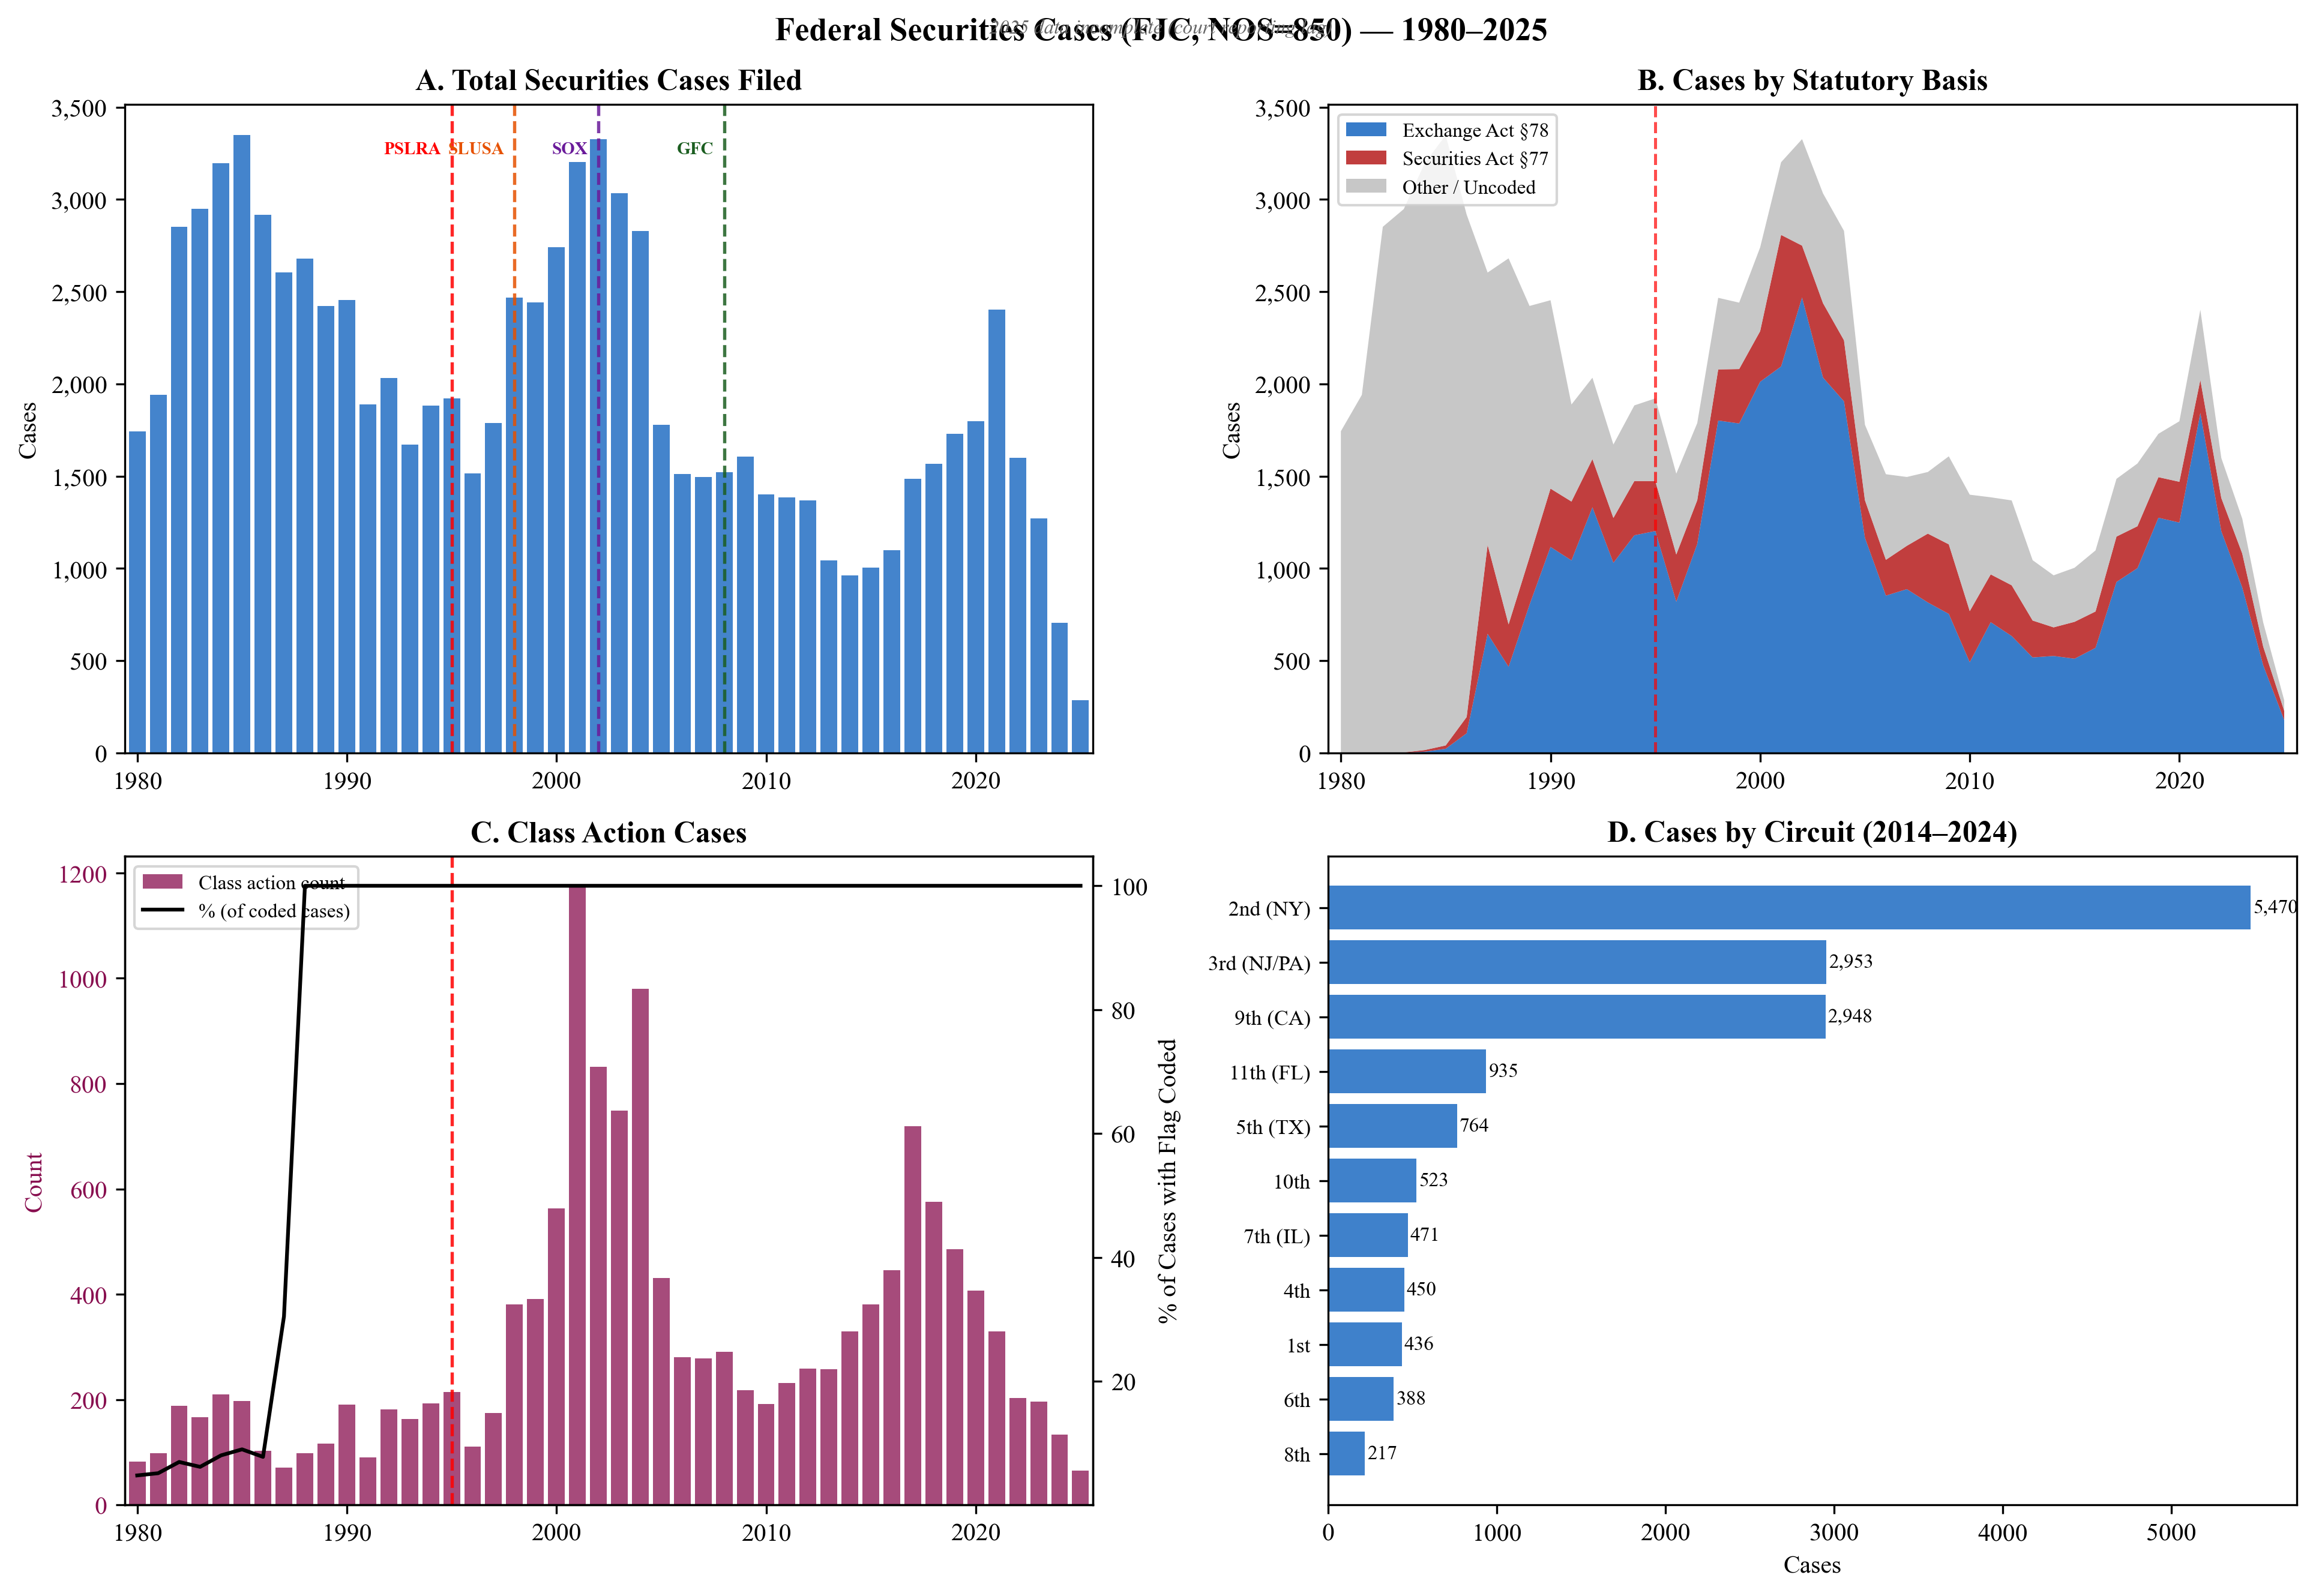

In [7]:
import os

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'Federal Securities Cases (FJC, NOS=850) — {annual["fileyear"].min()}–{annual["fileyear"].max()}',
             fontsize=13, fontweight='bold')
fig.text(0.5, 0.97, f'{annual["fileyear"].max()} data incomplete (court reporting lag)',
         ha='center', fontsize=8, color='#666666', style='italic')

yr = annual['fileyear'].values
EVENTS = [
    (1995, 'PSLRA', 'red'),
    (1998, 'SLUSA', '#E65100'),
    (2002, 'SOX',   '#6A1B9A'),
    (2008, 'GFC',   '#1B5E20'),
]

# A: Total filings
ax = axes[0, 0]
ax.bar(yr, annual['n_total'], color='#1565C0', alpha=0.8, width=0.8)
for year, label, color in EVENTS:
    ax.axvline(year, color=color, linestyle='--', linewidth=1.3, alpha=0.85)
    ax.text(year - 0.5, annual['n_total'].max() * 0.97, label, fontsize=7,
            color=color, ha='right', fontweight='bold')
ax.set_title('A. Total Securities Cases Filed', fontweight='bold')
ax.set_ylabel('Cases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_xlim(yr.min() - 0.6, yr.max() + 0.6)

# B: By statute
ax = axes[0, 1]
ax.stackplot(
    annual_statute['fileyear'],
    annual_statute['Exchange Act (SEA 1934)'],
    annual_statute['Securities Act (SA 1933)'],
    annual_statute['Other / Not Coded'],
    labels=['Exchange Act §78', 'Securities Act §77', 'Other / Uncoded'],
    colors=['#1565C0', '#B71C1C', '#BDBDBD'], alpha=0.85
)
ax.axvline(1995, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_title('B. Cases by Statutory Basis', fontweight='bold')
ax.set_ylabel('Cases')
ax.legend(fontsize=8, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_xlim(yr.min() - 0.6, yr.max() + 0.6)

# C: Class actions
ax = axes[1, 0]
ax2 = ax.twinx()
ax.bar(yr, annual['n_class_action'], color='#880E4F', alpha=0.75, width=0.8, label='Class action count')
ax2.plot(annual['fileyear'], annual['ca_share'], color='black', linewidth=1.5, label='% (of coded cases)')
ax.axvline(1995, color='red', linestyle='--', linewidth=1.3, alpha=0.85)
ax.set_title('C. Class Action Cases', fontweight='bold')
ax.set_ylabel('Count', color='#880E4F')
ax2.set_ylabel('% of Cases with Flag Coded')
ax.tick_params(axis='y', labelcolor='#880E4F')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
ax.set_xlim(yr.min() - 0.6, yr.max() + 0.6)

# D: Circuit distribution (2014–2024)
ax = axes[1, 1]
circuit_labels = {1:'1st',2:'2nd (NY)',3:'3rd (NJ/PA)',4:'4th',5:'5th (TX)',
                  6:'6th',7:'7th (IL)',8:'8th',9:'9th (CA)',10:'10th',11:'11th (FL)',12:'DC'}
recent = df[df['fileyear'].between(2014, 2024)]
circ = recent[recent['circuit'].between(1, 12)].groupby('circuit').size().sort_values(ascending=True)
labels_c = [circuit_labels.get(int(c), str(int(c))) for c in circ.index]
ax.barh(range(len(labels_c)), circ.values, color='#1565C0', alpha=0.82)
ax.set_yticks(range(len(labels_c)))
ax.set_yticklabels(labels_c, fontsize=8.5)
ax.set_title('D. Cases by Circuit (2014–2024)', fontweight='bold')
ax.set_xlabel('Cases')
for i, v in enumerate(circ.values):
    ax.text(v + 15, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
out_path = os.path.expanduser('~/areas/secreg/output/fjc-plots/fjc_fig1_overview.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## 5. PSLRA Impact Analysis

In [8]:
pre  = annual[annual['fileyear'].between(1985, 1994)]
post = annual[annual['fileyear'].between(1996, 2005)]

print('Pre-PSLRA (1985–94):')
print(f'  Avg total cases/yr:        {pre["n_total"].mean():.0f}')
print(f'  Avg class actions/yr:      {pre["n_class_action"].mean():.0f}')
print()
print('Post-PSLRA (1996–05):')
print(f'  Avg total cases/yr:        {post["n_total"].mean():.0f}')
print(f'  Avg class actions/yr:      {post["n_class_action"].mean():.0f}')
print()
print('Note: PSLRA raised pleading standards but class action filings *increased* post-1995.')
print('Interpretation: PSLRA shifted mix toward stronger cases, but did not deter filing volume.')

Pre-PSLRA (1985–94):
  Avg total cases/yr:        2391
  Avg class actions/yr:      140

Post-PSLRA (1996–05):
  Avg total cases/yr:        2512
  Avg class actions/yr:      578

Note: PSLRA raised pleading standards but class action filings *increased* post-1995.
Interpretation: PSLRA shifted mix toward stronger cases, but did not deter filing volume.


## 6. Disposition Analysis

In [9]:
def disp_cat(d):
    if pd.isna(d): return 'Unknown'
    d = int(d)
    if d <= 2:        return 'Transfer / Remand'
    if 10 <= d <= 19: return 'Dismissed (pre-trial)'
    if 20 <= d <= 29: return 'Trial Judgment'
    if 30 <= d <= 45: return 'Settlement / Consent'
    return 'Other'

df['disp_cat'] = df['disp'].apply(disp_cat)

post95 = df[df['fileyear'] >= 1995]
print('Disposition (post-PSLRA, 1995–2023):')
disp_pct = post95['disp_cat'].value_counts() / len(post95) * 100
print(disp_pct.round(1).to_string())
print()
print('Class actions only (post-PSLRA):')
ca_post95 = post95[post95['class_action'] == 1]
disp_ca = ca_post95['disp_cat'].value_counts() / len(ca_post95) * 100
print(disp_ca.round(1).to_string())

Disposition (post-PSLRA, 1995–2023):
disp_cat
Dismissed (pre-trial)    72.5
Other                    20.5
Transfer / Remand         7.0
Trial Judgment            0.0

Class actions only (post-PSLRA):
disp_cat
Dismissed (pre-trial)    72.0
Other                    21.6
Transfer / Remand         6.4
Trial Judgment            0.0


## 7. Linking to Compustat / EDGAR via `fjc_linking`

In [10]:
conn3 = psycopg2.connect(
    host='wrds-pgdata.wharton.upenn.edu', port=9737,
    database='wrds', user='eddyhu', sslmode='require'
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    df_link = pd.read_sql("""
        SELECT
            l.def_gvkey, l.def_cik, l.def_com_name, l.d_score,
            l.plt_gvkey, l.plt_cik, l.plt_com_name, l.p_score,
            l.filedate, l.circuit, l.district, l.docket
        FROM fjc_linking.wrds_civil_link l
        WHERE l.filedate >= '1990-01-01'
    """, conn3, parse_dates=['filedate'])
conn3.close()

print(f'Link table rows: {len(df_link):,}')
print(f'With defendant gvkey: {df_link["def_gvkey"].notna().sum():,}')
print(f'With defendant CIK:   {df_link["def_cik"].notna().sum():,}')
print(f'High-confidence def matches (d_score=1): {(df_link["d_score"]==1).sum():,}')
df_link.head(3)

Link table rows: 307,516
With defendant gvkey: 215,931
With defendant CIK:   279,384
High-confidence def matches (d_score=1): 68,850


,def_gvkey,def_cik,def_com_name,d_score,plt_gvkey,plt_cik,plt_com_name,p_score,filedate,circuit,district,docket
0,None,000000001848,ABERCROMBIE & FITCH CO,1.0,None,None,None,NaN,2005-04-14,11.0,3J,0500057
1,None,000000001904,ABRAHAM & CO.,4.0,None,None,None,NaN,2017-01-20,11.0,3C,1720252
2,None,000000001904,ABRAHAM & CO.,4.0,None,None,None,NaN,2016-05-05,2.0,07,1602257


In [11]:
conn4 = psycopg2.connect(
    host='wrds-pgdata.wharton.upenn.edu', port=9737,
    database='wrds', user='eddyhu', sslmode='require'
)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    df_merged = pd.read_sql("""
        SELECT
            c.filedate,
            EXTRACT(YEAR FROM c.filedate)::int AS fileyear,
            c.nos, c.section, c.subsect, c.class_action, c.disp, c.circuit::int, c.district,
            l.def_gvkey, l.def_cik, l.def_com_name, l.d_score
        FROM fjc.civil c
        JOIN fjc_linking.wrds_civil_link l
          ON c.filedate  = l.filedate
         AND c.docket    = l.docket
         AND c.circuit   = l.circuit
         AND c.district  = l.district
         AND c.office    = l.office
        WHERE c.nos = 850
          AND c.filedate >= '1990-01-01'
          AND l.d_score = 1  -- high-confidence defendant match only
    """, conn4, parse_dates=['filedate'])
conn4.close()

print(f'NOS=850 cases with high-confidence defendant match: {len(df_merged):,}')
df_merged.head(3)

NOS=850 cases with high-confidence defendant match: 0


,filedate,fileyear,nos,section,subsect,class_action,disp,circuit,district,def_gvkey,def_cik,def_com_name,d_score


## 8. Summary Statistics Table

In [12]:
summary = pd.DataFrame({
    'Metric': [
        'Total NOS=850 cases (1980–2024)',
        'Exchange Act §78',
        'Securities Act §77',
        'Other / Not Coded',
        'Class actions (where coded)',
        'Pre-PSLRA avg class actions/yr (1985–94)',
        'Post-PSLRA avg class actions/yr (1996–05)',
        'Dismissed pre-trial (post-1995)',
        'Reached trial (post-1995)',
    ],
    'Value': [
        f"{len(df):,}",
        f"{(df['statute']=='Exchange Act (SEA 1934)').sum():,} ({(df['statute']=='Exchange Act (SEA 1934)').mean()*100:.1f}%)",
        f"{(df['statute']=='Securities Act (SA 1933)').sum():,} ({(df['statute']=='Securities Act (SA 1933)').mean()*100:.1f}%)",
        f"{(df['statute']=='Other / Not Coded').sum():,} ({(df['statute']=='Other / Not Coded').mean()*100:.1f}%)",
        f"{(df['class_action']==1).sum():,} ({(df['class_action']==1).sum()/df['class_action'].notna().sum()*100:.1f}% of coded)",
        f"~{pre['n_class_action'].mean():.0f}",
        f"~{post['n_class_action'].mean():.0f}",
        f"{(post95['disp_cat']=='Dismissed (pre-trial)').mean()*100:.1f}%",
        f"{(post95['disp_cat']=='Trial Judgment').mean()*100:.1f}%",
    ]
})
display(summary)

,Metric,Value
0,Total NOS=850 cases (1980–2024),"90,882"
1,Exchange Act §78,"42,512 (46.8%)"
2,Securities Act §77,"10,411 (11.5%)"
3,Other / Not Coded,"37,959 (41.8%)"
4,Class actions (where coded),"14,424 (50.3% of coded)"
5,Pre-PSLRA avg class actions/yr (1985–94),~140
6,Post-PSLRA avg class actions/yr (1996–05),~578
7,Dismissed pre-trial (post-1995),72.5%
8,Reached trial (post-1995),0.0%


## 9. NBER Recession Dates

Hardcoded from [NBER Business Cycle Dating](https://www.nber.org/research/data/us-business-cycle-expansions-and-contractions). More reliable than a live FRED fetch for a committed notebook.

In [13]:
# NBER recession periods — (peak, trough) as year-month strings
# Source: https://www.nber.org/research/data/us-business-cycle-expansions-and-contractions
NBER_RECESSIONS = [
    ('1980-01', '1980-07'),   # Jan–Jul 1980
    ('1981-07', '1982-11'),   # Jul 1981 – Nov 1982
    ('1990-07', '1991-03'),   # Jul 1990 – Mar 1991
    ('2001-03', '2001-11'),   # Mar 2001 – Nov 2001
    ('2007-12', '2009-06'),   # Dec 2007 – Jun 2009 (Great Recession)
    ('2020-02', '2020-04'),   # Feb 2020 – Apr 2020 (COVID)
]

def add_recession_shading(ax, recessions=NBER_RECESSIONS, alpha=0.15, color='grey'):
    """Add NBER recession shading to a matplotlib axis with an annual x-axis."""
    for start, end in recessions:
        s = pd.Period(start, 'M').to_timestamp().year + pd.Period(start, 'M').month / 12
        e = pd.Period(end,   'M').to_timestamp().year + pd.Period(end,   'M').month / 12
        ax.axvspan(s, e, alpha=alpha, color=color, zorder=0)

print("NBER recession helper defined.")
print("Recessions covered:", [r[0] for r in NBER_RECESSIONS])

NBER recession helper defined.
Recessions covered: ['1980-01', '1981-07', '1990-07', '2001-03', '2007-12', '2020-02']


## 10. Bankruptcy Filings (`fjc.bankruptcy`)

**Dedup note:** `fjc.bankruptcy` is a snapshot panel (annual snapshots, Sep 30 each year).
Always use `COUNT(DISTINCT casekey)`. Reliable coverage: **2008–2024** — pre-2008 cases
that closed before the first snapshot (2008-09-30) are absent from the database.

**Pre-2008 data:** Not available in WRDS FJC. For historical bankruptcy trends before 2008,
see the Administrative Office of U.S. Courts statistics at uscourts.gov.


In [14]:
conn_bk = psycopg2.connect(
    host='wrds-pgdata.wharton.upenn.edu', port=9737,
    database='wrds', user='eddyhu', sslmode='require'
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    df_bk = pd.read_sql("""
        SELECT
            EXTRACT(YEAR FROM orgfldt)::int AS yr,
            orgflchp                        AS chapter,
            ntrdbt                          AS nature_debt,
            COUNT(DISTINCT casekey)         AS n_cases
        FROM fjc.bankruptcy
        WHERE orgfldt >= '2008-01-01'
          AND casekey IS NOT NULL
        GROUP BY yr, chapter, ntrdbt
        ORDER BY yr, chapter
    """, conn_bk)
conn_bk.close()

# Chapter labels
CH_MAP = {'7': 'Ch.7 (Liquidation)', '11': 'Ch.11 (Reorganization)',
          '12': 'Ch.12 (Family Farm)', '13': 'Ch.13 (Wage Earner)'}
ND_MAP = {'b': 'Business', 'c': 'Consumer', 'o': 'Other'}

df_bk['ch_label'] = df_bk['chapter'].map(CH_MAP).fillna('Other')
df_bk['nd_label'] = df_bk['nature_debt'].map(ND_MAP).fillna('Unknown/None')

bk_total  = df_bk.groupby('yr')['n_cases'].sum()
bk_by_ch  = df_bk.groupby(['yr', 'ch_label'])['n_cases'].sum().unstack(fill_value=0)
bk_by_nd  = df_bk.groupby(['yr', 'nd_label'])['n_cases'].sum().unstack(fill_value=0)

print("Annual bankruptcy filings (DISTINCT casekey, 2008–2024):")
display(bk_by_ch.assign(Total=bk_total))
print()
print("Business vs. Consumer:")
display(bk_by_nd.assign(Total=bk_total))

Annual bankruptcy filings (DISTINCT casekey, 2008–2024):


ch_label,Ch.11 (Reorganization),Ch.12 (Family Farm),Ch.13 (Wage Earner),Ch.7 (Liquidation),Other,Total
yr,,,,,,
2008,10635,357,374487,765893,85,1151457
2009,16115,557,415146,1066436,150,1498404
2010,14728,754,445016,1146996,138,1607632
2011,12442,657,409158,995549,75,1417881
2012,10895,523,364962,841577,146,1218103
2013,9223,394,326519,721592,99,1057827
2014,7219,368,307600,615264,82,930533
2015,7018,402,298642,530153,100,836315
2016,6924,464,293579,485750,187,786904



Business vs. Consumer:


nd_label,Business,Consumer,Other,Unknown/None,Total
yr,,,,,
2008,45555,1105902,0,0,1151457
2009,62775,1435629,0,0,1498404
2010,57901,1549731,0,0,1607632
2011,48854,1369027,0,0,1417881
2012,40267,1177836,0,0,1218103
2013,32815,1025012,0,0,1057827
2014,26633,903899,0,1,930533
2015,24178,812034,99,4,836315
2016,23375,761929,1420,180,786904


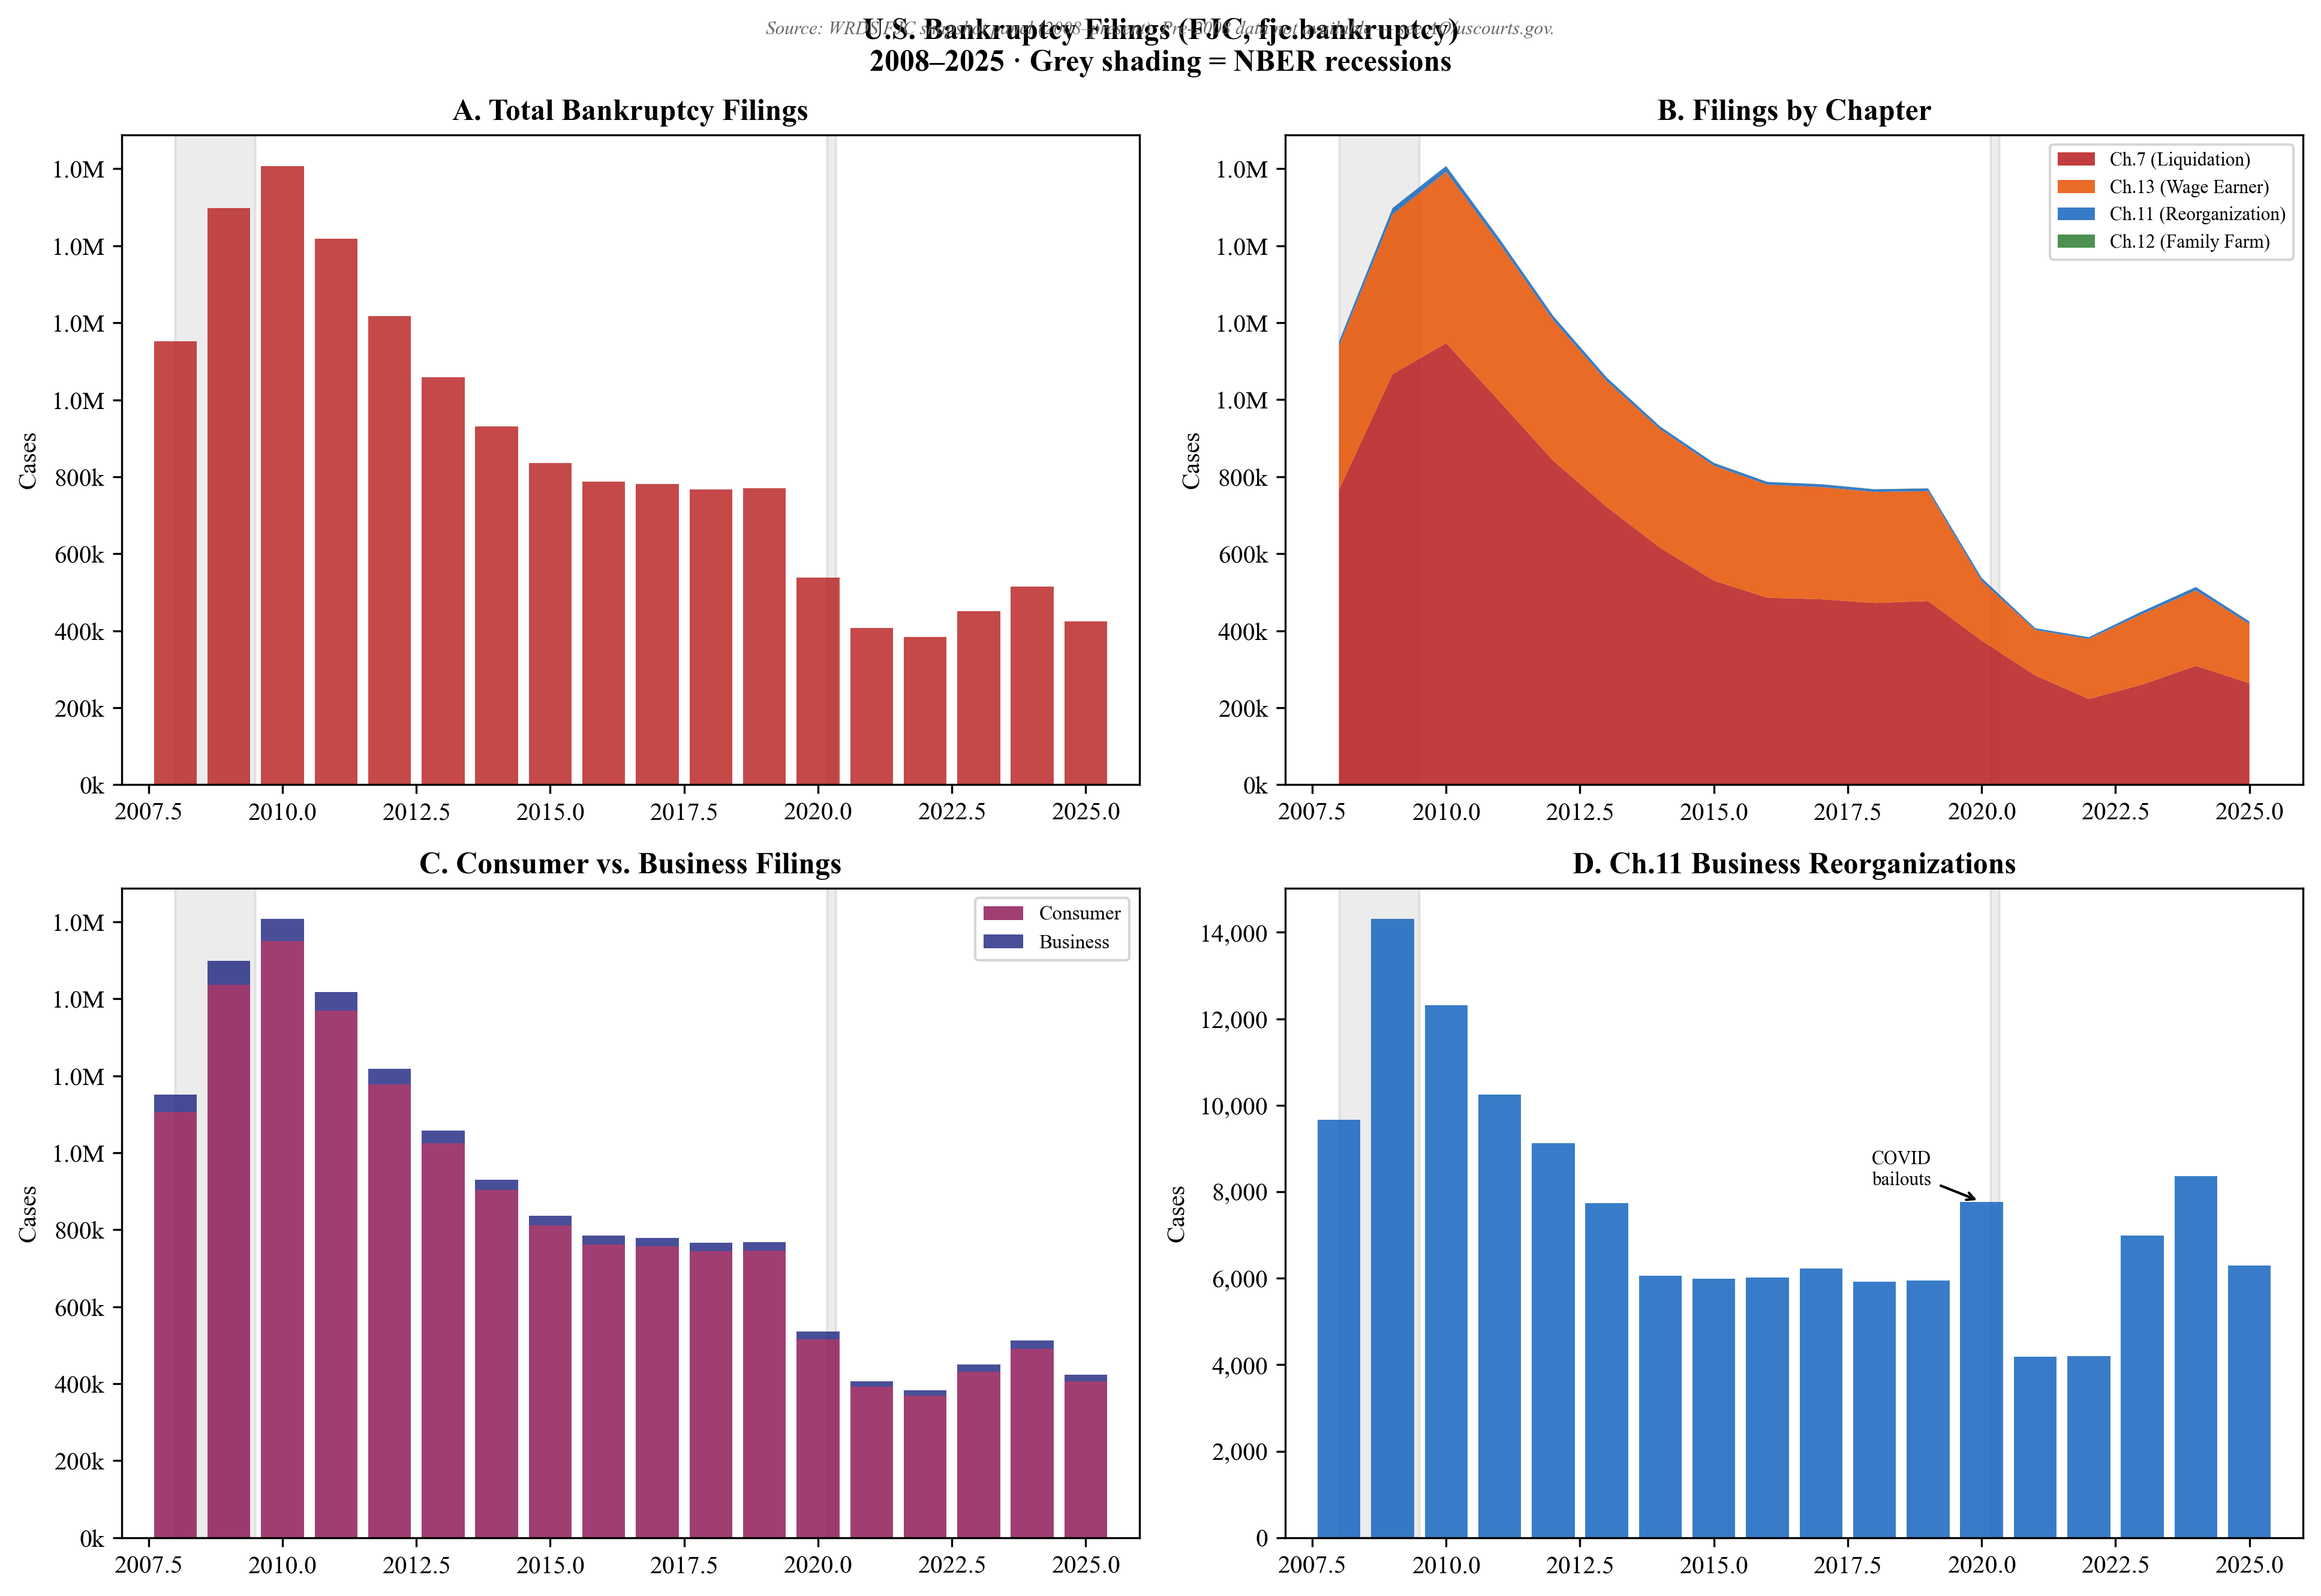

Saved: /Users/vwh7mb/areas/secreg/output/fjc-plots/fjc_fig3_bankruptcy.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'U.S. Bankruptcy Filings (FJC, fjc.bankruptcy)\n{bk_total.index.min()}–{bk_total.index.max()} · Grey shading = NBER recessions',
             fontsize=12, fontweight='bold')
fig.text(0.5, 0.97, 'Source: WRDS FJC snapshot panel (2008–present). Pre-2008 data not available — see AO/uscourts.gov.',
         ha='center', fontsize=7.5, color='#666666', style='italic')

yr_bk = bk_total.index.values

# A: Total filings with recession shading
ax = axes[0, 0]
ax.bar(yr_bk, bk_total.values, color='#B71C1C', alpha=0.8, width=0.8)
add_recession_shading(ax)
ax.set_title('A. Total Bankruptcy Filings', fontweight='bold')
ax.set_ylabel('Cases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x/1e6):.1f}M' if x >= 1e6 else f'{int(x/1e3):.0f}k'))
ax.set_xlim(yr_bk.min() - 1, yr_bk.max() + 1)

# B: By chapter (stacked)
ax = axes[0, 1]
ch_cols = ['Ch.7 (Liquidation)', 'Ch.13 (Wage Earner)', 'Ch.11 (Reorganization)', 'Ch.12 (Family Farm)']
ch_cols = [c for c in ch_cols if c in bk_by_ch.columns]
colors_ch = ['#B71C1C', '#E65100', '#1565C0', '#2E7D32']
ax.stackplot(yr_bk,
             *[bk_by_ch.get(c, pd.Series(0, index=bk_by_ch.index)) for c in ch_cols],
             labels=ch_cols, colors=colors_ch[:len(ch_cols)], alpha=0.85)
add_recession_shading(ax)
ax.set_title('B. Filings by Chapter', fontweight='bold')
ax.set_ylabel('Cases')
ax.legend(fontsize=7.5, loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x/1e6):.1f}M' if x >= 1e6 else f'{int(x/1e3):.0f}k'))
ax.set_xlim(yr_bk.min() - 1, yr_bk.max() + 1)

# C: Business vs Consumer
ax = axes[1, 0]
if 'Consumer' in bk_by_nd.columns:
    ax.bar(yr_bk, bk_by_nd.get('Consumer', 0), color='#880E4F', alpha=0.8, width=0.8, label='Consumer')
if 'Business' in bk_by_nd.columns:
    ax.bar(yr_bk, bk_by_nd.get('Business', 0),
           bottom=bk_by_nd.get('Consumer', pd.Series(0, index=bk_by_nd.index)),
           color='#1A237E', alpha=0.8, width=0.8, label='Business')
add_recession_shading(ax)
ax.set_title('C. Consumer vs. Business Filings', fontweight='bold')
ax.set_ylabel('Cases')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x/1e6):.1f}M' if x >= 1e6 else f'{int(x/1e3):.0f}k'))
ax.set_xlim(yr_bk.min() - 1, yr_bk.max() + 1)

# D: Ch.11 business reorganizations (law student focus)
ax = axes[1, 1]
ch11_biz = df_bk[(df_bk['chapter'] == '11') & (df_bk['nature_debt'] == 'b')].groupby('yr')['n_cases'].sum()
ax.bar(ch11_biz.index, ch11_biz.values, color='#1565C0', alpha=0.85, width=0.8)
add_recession_shading(ax)
ax.set_title('D. Ch.11 Business Reorganizations', fontweight='bold')
ax.set_ylabel('Cases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.set_xlim(yr_bk.min() - 1, yr_bk.max() + 1)
# Annotate COVID bump
ax.annotate('COVID\nbailouts', xy=(2020, ch11_biz.get(2020, 0)),
            xytext=(2018.5, ch11_biz.get(2020, 0) * 1.05),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=7.5, ha='center')

plt.tight_layout()
out_path = os.path.expanduser('~/areas/secreg/output/fjc-plots/fjc_fig3_bankruptcy.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {out_path}")